risk_band
Low Risk       4106
High Risk      4101
Medium Risk    4096
Name: count, dtype: int64


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


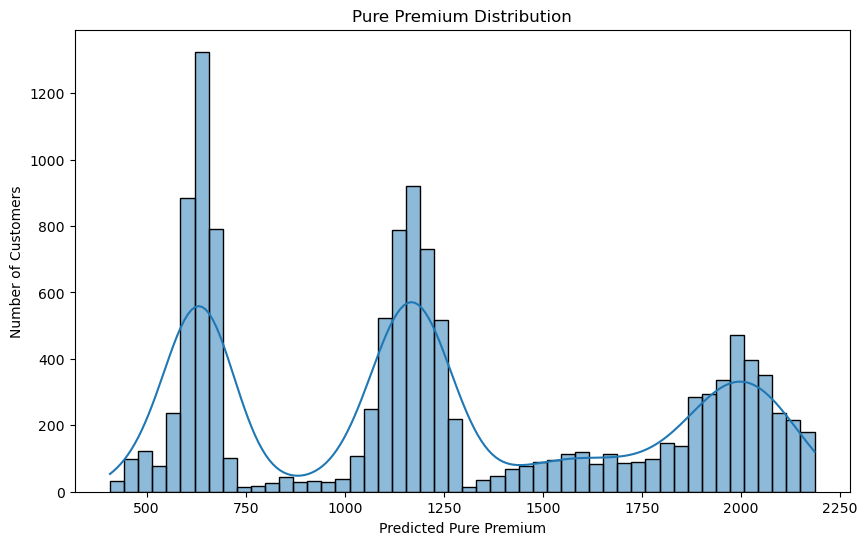

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


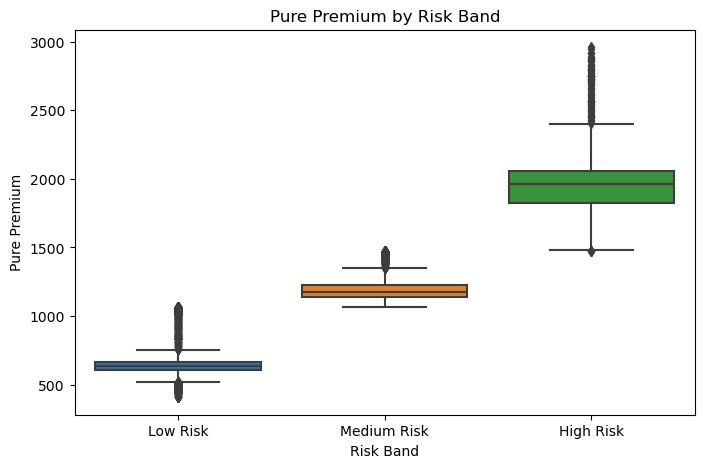

In [3]:

# IMPORTS


import pandas as pd
import sqlite3
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns



# LOAD DATA 

conn = sqlite3.connect("Insurance_project.db")

query = """
SELECT 
    p.customerid,
    cst.age,
    cst.gender,
    p.coveragetype,
    COUNT(cl.claimsid) AS number_of_claims,
    SUM(cl.amount) AS total_claim_amount,
    AVG(cl.amount) AS avg_claim_amount
FROM policy p

LEFT JOIN claims cl
    ON p.policyid = cl.policyid
    AND cl.amount > 0

INNER JOIN customers cst
    ON p.customerid = cst.customerid

GROUP BY 
    p.customerid,
    cst.age,
    cst.gender,
    p.coveragetype;
"""

df = pd.read_sql_query(query, conn)
conn.close()



# CLEAN DATA


df.columns = [
    "customer_id",
    "age",
    "gender",
    "coverage_type",
    "number_of_claims",
    "total_claim_amount",
    "avg_claim_amount"
]

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["number_of_claims"] = pd.to_numeric(df["number_of_claims"], errors="coerce").fillna(0)
df["avg_claim_amount"] = pd.to_numeric(df["avg_claim_amount"], errors="coerce")

df = df[df["age"].notnull()]
df = df[df["coverage_type"].notnull()]



# FREQUENCY MODEL (POISSON)


freq_df = df.copy()

freq_X = freq_df[["age", "gender", "coverage_type"]]
freq_X = pd.get_dummies(freq_X, drop_first=True)
freq_X = sm.add_constant(freq_X).astype(float)

y_freq = freq_df["number_of_claims"].astype(float)

freq_model = sm.GLM(
    y_freq,
    freq_X,
    family=sm.families.Poisson()
)

freq_result = freq_model.fit()

freq_df["predicted_claim_frequency"] = freq_result.predict(freq_X)



# SEVERITY MODEL (GAMMA)


# ONLY CLAIMANTS (CRITICAL FIX)
sev_df = df[df["number_of_claims"] > 0].copy()

sev_X = sev_df[[
    "age",
    "gender",
    "coverage_type",
    "number_of_claims"
]]

sev_X = pd.get_dummies(sev_X, drop_first=True)
sev_X = sm.add_constant(sev_X).astype(float)

y_sev = sev_df["avg_claim_amount"].astype(float)

sev_model = sm.GLM(
    y_sev,
    sev_X,
    family=sm.families.Gamma(link=sm.families.links.Log())
)

sev_result = sev_model.fit()

sev_df["predicted_severity"] = sev_result.predict(sev_X)



# MERGE RESULTS


df = freq_df.merge(
    sev_df[["customer_id", "predicted_severity"]],
    on="customer_id",
    how="left"
)

# Fill missing severity for non-claimants 
df["predicted_severity"] = df["predicted_severity"].fillna(
    sev_df["avg_claim_amount"].mean()
)



# PURE PREMIUM

df["pure_premium"] = (
    df["predicted_claim_frequency"] *
    df["predicted_severity"]
)



# RISK BANDS


df["risk_band"] = pd.qcut(
    df["pure_premium"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print(df["risk_band"].value_counts())



# PURE PREMIUM DISTRIBUTION


pp = df["pure_premium"]
pp = pp[pp < pp.quantile(0.99)]

plt.figure(figsize=(10,6))
sns.histplot(pp, bins=50, kde=True)

plt.title("Pure Premium Distribution")
plt.xlabel("Predicted Pure Premium")
plt.ylabel("Number of Customers")
plt.show()



# RISK BAND VISUALISATION


plt.figure(figsize=(8,5))

sns.boxplot(
    x="risk_band",
    y="pure_premium",
    data=df,
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Pure Premium by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Pure Premium")

plt.show()

**Claim frequency increases by 10%**

risk_band
Low Risk       4106
High Risk      4101
Medium Risk    4096
Name: count, dtype: int64


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


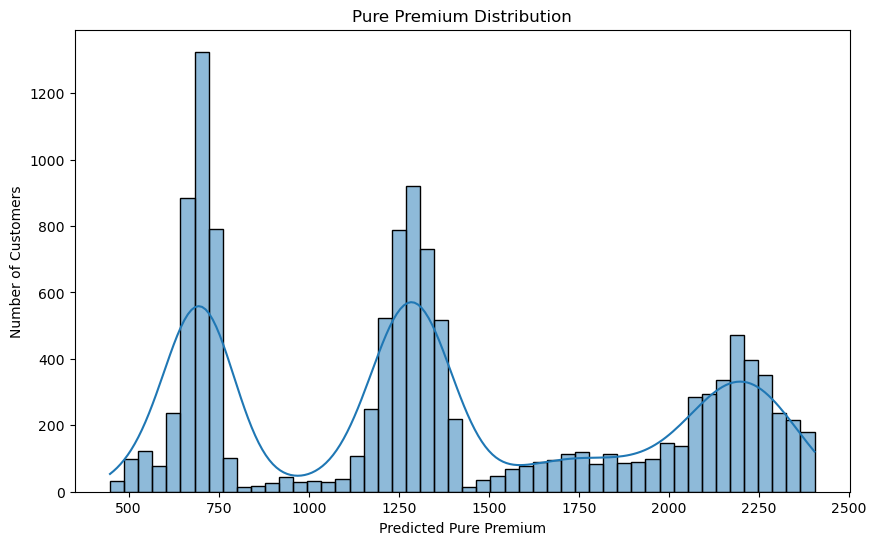

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


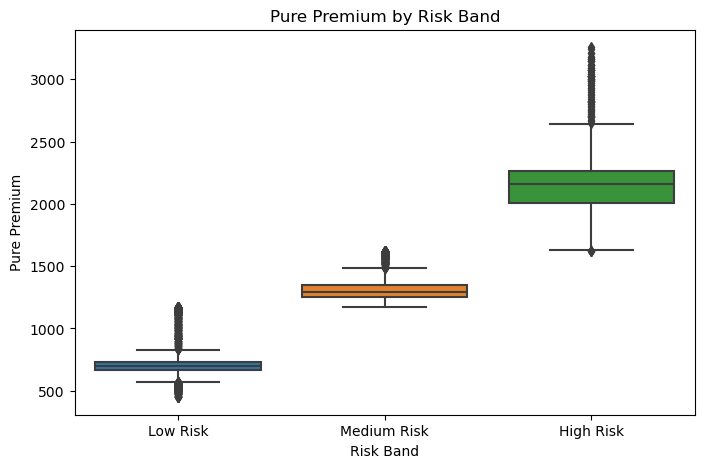

In [5]:

# IMPORTS


import pandas as pd
import sqlite3
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns



# LOAD DATA 

conn = sqlite3.connect("Insurance_project.db")

query = """
SELECT 
    p.customerid,
    cst.age,
    cst.gender,
    p.coveragetype,
    COUNT(cl.claimsid) AS number_of_claims,
    SUM(cl.amount) AS total_claim_amount,
    AVG(cl.amount) AS avg_claim_amount
FROM policy p

LEFT JOIN claims cl
    ON p.policyid = cl.policyid
    AND cl.amount > 0

INNER JOIN customers cst
    ON p.customerid = cst.customerid

GROUP BY 
    p.customerid,
    cst.age,
    cst.gender,
    p.coveragetype;
"""

df = pd.read_sql_query(query, conn)
conn.close()



# CLEAN DATA


df.columns = [
    "customer_id",
    "age",
    "gender",
    "coverage_type",
    "number_of_claims",
    "total_claim_amount",
    "avg_claim_amount"
]

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["number_of_claims"] = pd.to_numeric(df["number_of_claims"], errors="coerce").fillna(0)
df["avg_claim_amount"] = pd.to_numeric(df["avg_claim_amount"], errors="coerce")

df = df[df["age"].notnull()]
df = df[df["coverage_type"].notnull()]



# FREQUENCY MODEL (POISSON)


freq_df = df.copy()

freq_X = freq_df[["age", "gender", "coverage_type"]]
freq_X = pd.get_dummies(freq_X, drop_first=True)
freq_X = sm.add_constant(freq_X).astype(float)

y_freq = freq_df["number_of_claims"].astype(float)

freq_model = sm.GLM(
    y_freq,
    freq_X,
    family=sm.families.Poisson()
)

freq_result = freq_model.fit()

freq_df["predicted_claim_frequency"] = freq_result.predict(freq_X)



# SEVERITY MODEL (GAMMA)


# ONLY CLAIMANTS 
sev_df = df[df["number_of_claims"] > 0].copy()

sev_X = sev_df[[
    "age",
    "gender",
    "coverage_type",
    "number_of_claims"
]]

sev_X = pd.get_dummies(sev_X, drop_first=True)
sev_X = sm.add_constant(sev_X).astype(float)

y_sev = sev_df["avg_claim_amount"].astype(float)

sev_model = sm.GLM(
    y_sev,
    sev_X,
    family=sm.families.Gamma(link=sm.families.links.Log())
)

sev_result = sev_model.fit()

sev_df["predicted_severity"] = sev_result.predict(sev_X)



# MERGE RESULTS


df = freq_df.merge(
    sev_df[["customer_id", "predicted_severity"]],
    on="customer_id",
    how="left"
)

# Fill missing severity for non-claimants 
df["predicted_severity"] = df["predicted_severity"].fillna(
    sev_df["avg_claim_amount"].mean()
)



# PURE PREMIUM

df["pure_premium"] = (
    (df["predicted_claim_frequency"]*1.1) *
    df["predicted_severity"]
)



# RISK BANDS


df["risk_band"] = pd.qcut(
    df["pure_premium"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print(df["risk_band"].value_counts())



# PURE PREMIUM DISTRIBUTION


pp = df["pure_premium"]
pp = pp[pp < pp.quantile(0.99)]

plt.figure(figsize=(10,6))
sns.histplot(pp, bins=50, kde=True)

plt.title("Pure Premium Distribution")
plt.xlabel("Predicted Pure Premium")
plt.ylabel("Number of Customers")
plt.show()



# RISK BAND VISUALISATION


plt.figure(figsize=(8,5))

sns.boxplot(
    x="risk_band",
    y="pure_premium",
    data=df,
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Pure Premium by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Pure Premium")

plt.show()

**Claim severity increases by 25%**

risk_band
Low Risk       4106
High Risk      4101
Medium Risk    4096
Name: count, dtype: int64


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


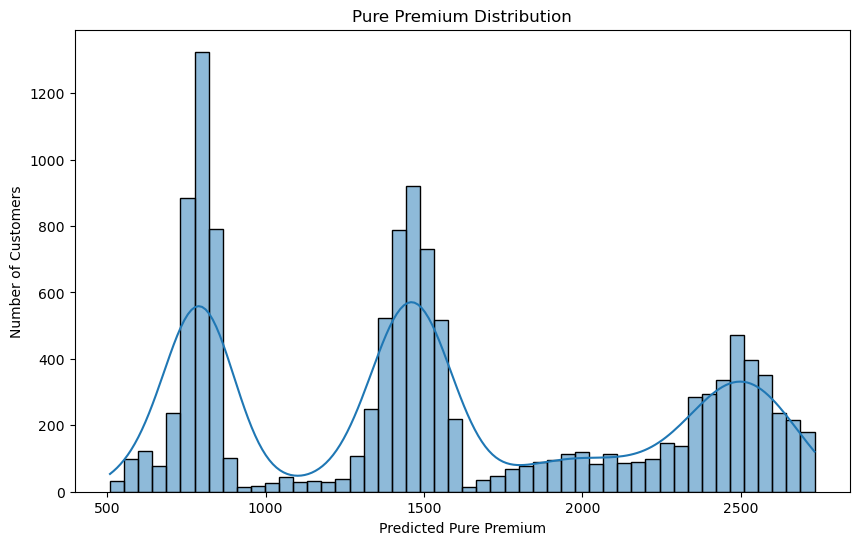

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


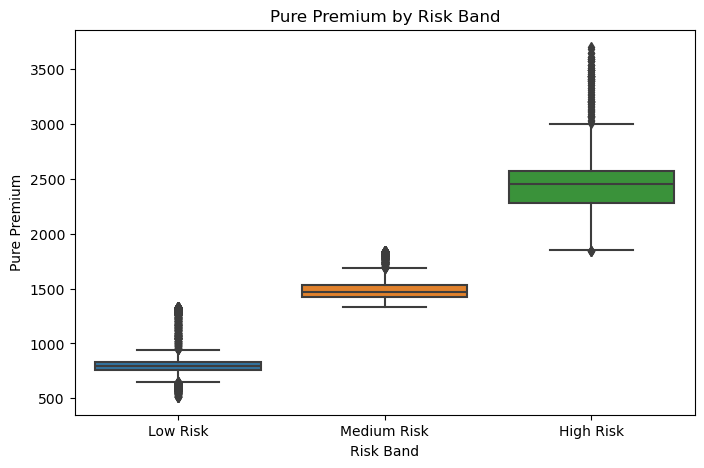

In [7]:

# IMPORTS


import pandas as pd
import sqlite3
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns



# LOAD DATA 

conn = sqlite3.connect("Insurance_project.db")

query = """
SELECT 
    p.customerid,
    cst.age,
    cst.gender,
    p.coveragetype,
    COUNT(cl.claimsid) AS number_of_claims,
    SUM(cl.amount) AS total_claim_amount,
    AVG(cl.amount) AS avg_claim_amount
FROM policy p

LEFT JOIN claims cl
    ON p.policyid = cl.policyid
    AND cl.amount > 0

INNER JOIN customers cst
    ON p.customerid = cst.customerid

GROUP BY 
    p.customerid,
    cst.age,
    cst.gender,
    p.coveragetype;
"""

df = pd.read_sql_query(query, conn)
conn.close()



# CLEAN DATA


df.columns = [
    "customer_id",
    "age",
    "gender",
    "coverage_type",
    "number_of_claims",
    "total_claim_amount",
    "avg_claim_amount"
]

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["number_of_claims"] = pd.to_numeric(df["number_of_claims"], errors="coerce").fillna(0)
df["avg_claim_amount"] = pd.to_numeric(df["avg_claim_amount"], errors="coerce")

df = df[df["age"].notnull()]
df = df[df["coverage_type"].notnull()]



# FREQUENCY MODEL (POISSON)


freq_df = df.copy()

freq_X = freq_df[["age", "gender", "coverage_type"]]
freq_X = pd.get_dummies(freq_X, drop_first=True)
freq_X = sm.add_constant(freq_X).astype(float)

y_freq = freq_df["number_of_claims"].astype(float)

freq_model = sm.GLM(
    y_freq,
    freq_X,
    family=sm.families.Poisson()
)

freq_result = freq_model.fit()

freq_df["predicted_claim_frequency"] = freq_result.predict(freq_X)



# SEVERITY MODEL (GAMMA)



sev_df = df[df["number_of_claims"] > 0].copy()

sev_X = sev_df[[
    "age",
    "gender",
    "coverage_type",
    "number_of_claims"
]]

sev_X = pd.get_dummies(sev_X, drop_first=True)
sev_X = sm.add_constant(sev_X).astype(float)

y_sev = sev_df["avg_claim_amount"].astype(float)

sev_model = sm.GLM(
    y_sev,
    sev_X,
    family=sm.families.Gamma(link=sm.families.links.Log())
)

sev_result = sev_model.fit()

sev_df["predicted_severity"] = sev_result.predict(sev_X)



# MERGE RESULTS


df = freq_df.merge(
    sev_df[["customer_id", "predicted_severity"]],
    on="customer_id",
    how="left"
)

# Fill missing severity for non-claimants (optional assumption)
df["predicted_severity"] = df["predicted_severity"].fillna(
    sev_df["avg_claim_amount"].mean()
)



# PURE PREMIUM

df["pure_premium"] = (
    df["predicted_claim_frequency"] *
    (df["predicted_severity"]*1.25)
)



# RISK BANDS


df["risk_band"] = pd.qcut(
    df["pure_premium"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print(df["risk_band"].value_counts())



# PURE PREMIUM DISTRIBUTION


pp = df["pure_premium"]
pp = pp[pp < pp.quantile(0.99)]

plt.figure(figsize=(10,6))
sns.histplot(pp, bins=50, kde=True)

plt.title("Pure Premium Distribution")
plt.xlabel("Predicted Pure Premium")
plt.ylabel("Number of Customers")
plt.show()



# RISK BAND VISUALISATION


plt.figure(figsize=(8,5))

sns.boxplot(
    x="risk_band",
    y="pure_premium",
    data=df,
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Pure Premium by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Pure Premium")

plt.show()

**Catastrophe event**

In [11]:
# CATASTROPHIC EVENT


cat_df = df.copy()

# Randomly select 5% of customers
cat_mask = np.random.rand(len(cat_df)) < 0.05

# Increase severity by 400%
cat_df.loc[cat_mask, "predicted_severity"] *= 5

cat_df["catastrophe_pure_premium"] = (
    cat_df["predicted_claim_frequency"] *
    cat_df["predicted_severity"]
)

print("Baseline portfolio loss:")
print(df["pure_premium"].sum())

print("\nCatastrophe portfolio loss:")
print(cat_df["catastrophe_pure_premium"].sum())

Baseline portfolio loss:
15502664.237786004

Catastrophe portfolio loss:
18672005.254993107


In [12]:
baseline = df["pure_premium"].sum()
catastrophe = cat_df["catastrophe_pure_premium"].sum()

impact = catastrophe - baseline

print(f"Baseline Loss: £{baseline:,.0f}")
print(f"Catastrophe Loss: £{catastrophe:,.0f}")
print(f"Increase: £{impact:,.0f}")

Baseline Loss: £15,502,664
Catastrophe Loss: £18,672,005
Increase: £3,169,341


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


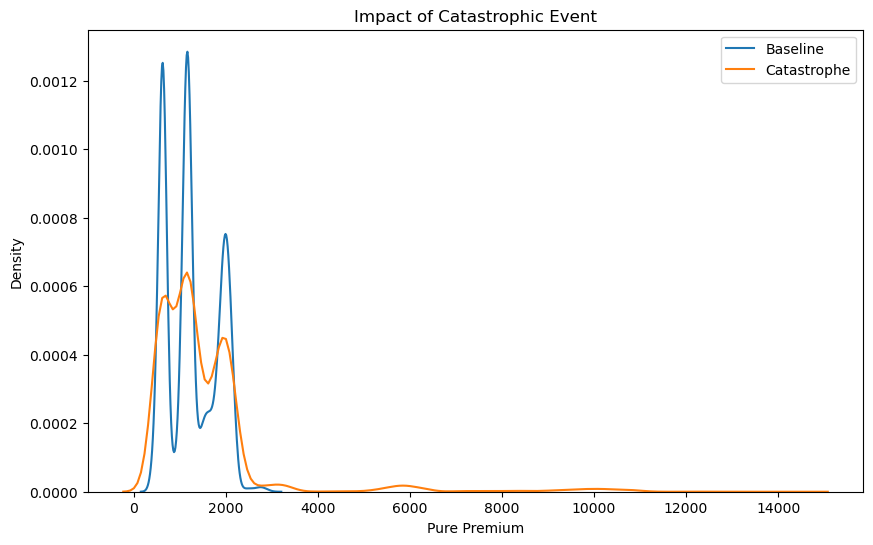

In [13]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    df["pure_premium"],
    label="Baseline"
)

sns.kdeplot(
    cat_df["catastrophe_pure_premium"],
    label="Catastrophe"
)

plt.title("Impact of Catastrophic Event")
plt.xlabel("Pure Premium")
plt.legend()

plt.show()

**Frequency stress testing**

In [14]:
scenarios = {
    "Baseline": 1.00,
    "Frequency +10%": 1.10,
    "Frequency +20%": 1.20,
    "Frequency +50%": 1.50
}

results = []

for name, factor in scenarios.items():

    stressed_loss = (
        df["predicted_claim_frequency"] *
        factor *
        df["predicted_severity"]
    ).sum()

    results.append([name, stressed_loss])

scenario_df = pd.DataFrame(
    results,
    columns=["Scenario", "Expected Loss"]
)

print(scenario_df)

         Scenario  Expected Loss
0        Baseline   1.550266e+07
1  Frequency +10%   1.705293e+07
2  Frequency +20%   1.860320e+07
3  Frequency +50%   2.325400e+07


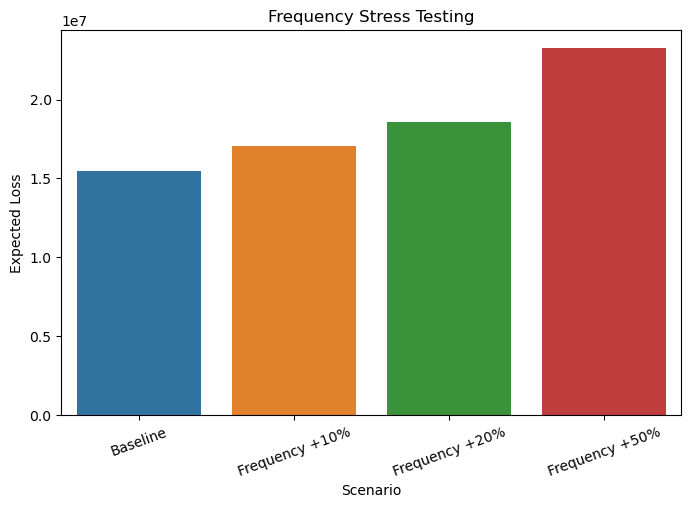

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=scenario_df,
    x="Scenario",
    y="Expected Loss"
)

plt.title("Frequency Stress Testing")
plt.xticks(rotation=20)

plt.show()

**Monte Carlo**

In [28]:
import numpy as np

n_simulations = 10000

freq = df["predicted_claim_frequency"].values
sev = df["predicted_severity"].values

portfolio_losses = np.zeros(n_simulations)

for sim in range(n_simulations):

    claims = np.random.poisson(freq)

    total_loss = 0

    for n_claims, mean_sev in zip(claims, sev):

        if n_claims > 0:

            total_loss += np.random.gamma(
                shape=2 * n_claims,
                scale=mean_sev / 2
            )

    portfolio_losses[sim] = total_loss

print(f"Mean Loss: £{portfolio_losses.mean():,.2f}")
print(f"95% VaR: £{np.percentile(portfolio_losses,95):,.2f}")
print(f"99% VaR: £{np.percentile(portfolio_losses,99):,.2f}")

Mean Loss: £15,510,454.15
95% VaR: £16,242,515.56
99% VaR: £16,548,646.56


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


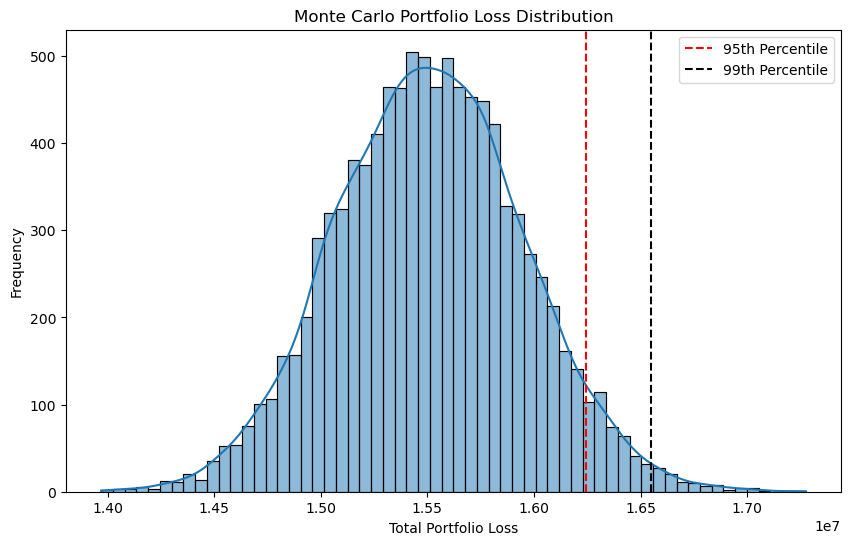

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    portfolio_losses,
    bins=60,
    kde=True
)

plt.axvline(
    np.percentile(portfolio_losses, 95),
    color="red",
    linestyle="--",
    label="95th Percentile"
)

plt.axvline(
    np.percentile(portfolio_losses, 99),
    color="black",
    linestyle="--",
    label="99th Percentile"
)

plt.title("Monte Carlo Portfolio Loss Distribution")
plt.xlabel("Total Portfolio Loss")
plt.ylabel("Frequency")

plt.legend()

plt.show()

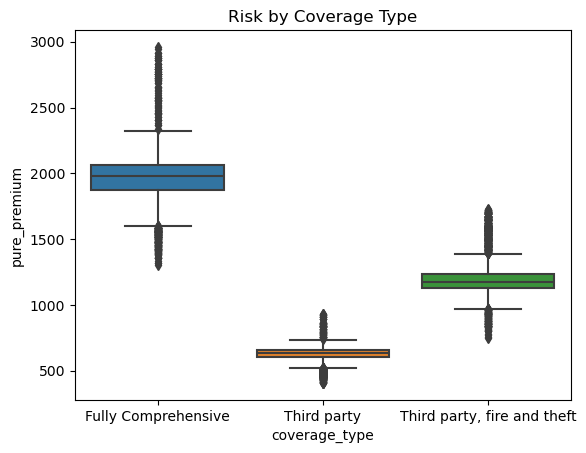

In [23]:
sns.boxplot(
    x="coverage_type",
    y="pure_premium",
    data=df
)
plt.title("Risk by Coverage Type")
plt.show()

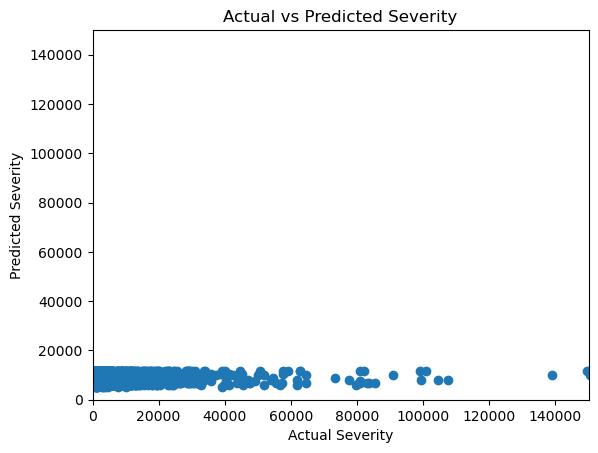

In [24]:
plt.scatter(
    df["avg_claim_amount"],
    df["predicted_severity"]
)

plt.xlabel("Actual Severity")
plt.xlim(0,150000)
plt.ylim(0,150000)
plt.ylabel("Predicted Severity")
plt.title("Actual vs Predicted Severity")
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='risk_band', ylabel='pure_premium'>

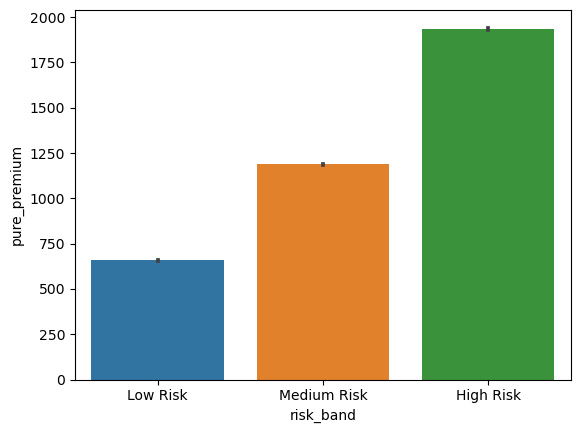

In [26]:
sns.barplot(
    x="risk_band",
    y="pure_premium",
    data=df
)